In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,Binarizer,Normalizer,OneHotEncoder,LabelEncoder

In [2]:
np.random.seed(5)
a = np.random.normal(0, 2, 10000)
b = np.random.normal(5, 3, 10000)
c = np.random.normal(-5, 5, 10000)

df = pd.DataFrame({
    'A' : a,
    'B' : b,
    'C' : c
})
df

,A,B,C
0,0.882455,1.466990,-7.089363
1,-0.661740,0.571914,-3.105893
2,4.861542,7.828852,-1.039068
3,-0.504184,5.001904,-9.755722
4,0.219220,1.731128,-7.679528
...,...,...,...
9995,-0.068972,3.739968,-4.303864
9996,-2.167260,0.681434,-9.584910
9997,2.188712,9.860986,-9.986860
9998,0.595445,5.982577,-11.128039


<Axes: ylabel='Density'>

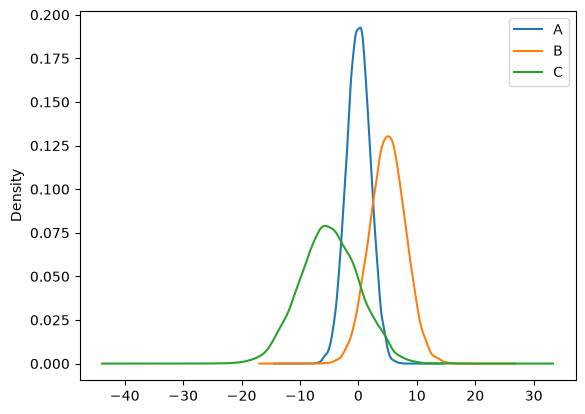

In [3]:
df.plot.kde()

In [4]:
scaler = StandardScaler()

In [5]:
scaled = scaler.fit_transform(df)

In [6]:
df = pd.DataFrame(scaled, columns=['A','B','C'])

<Axes: ylabel='Density'>

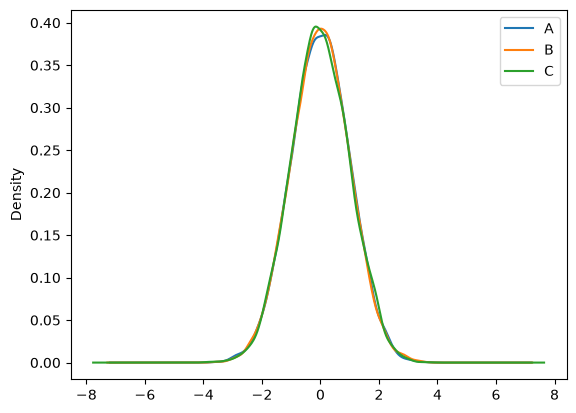

In [7]:

df.plot.kde()

In [8]:
minmax = MinMaxScaler()
mm_scaled = minmax.fit_transform(df)

<Axes: ylabel='Density'>

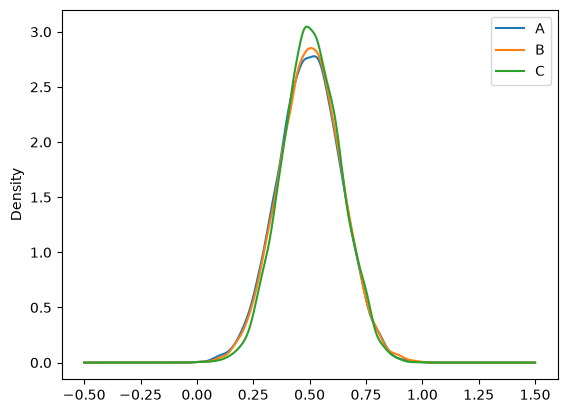

In [9]:
df = pd.DataFrame(mm_scaled,columns=['A','B','C'])
df.plot.kde()

In [10]:
rscaler = RobustScaler()

In [11]:



robust = rscaler.fit_transform(df)
df = pd.DataFrame(robust, columns=['A','B','C'])

<Axes: ylabel='Density'>

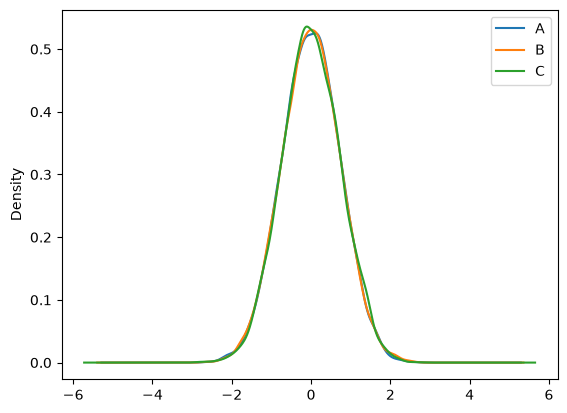

In [12]:
df.plot.kde()

In [13]:
binary = Binarizer(threshold=5)

a = np.array([[ 30, 10,  22],
              [ 20,  2,  10],
              [ 33,  5, 5]])

binary1 = binary.transform(a)
binary1

array([[1, 1, 1],
       [1, 0, 1],
       [1, 0, 0]])

In [14]:
X = [[5, 2, 3],
     [2, 4, 10],
     [6, 8, 6]]

sss = [np.sqrt(np.sum(np.power(X[i], 2))) for i in range(len(X))]

In [15]:
len(X)

3

In [16]:
np.array([X[k] / sss[k] for k in range(len(X))])

array([[0.81110711, 0.32444284, 0.48666426],
       [0.18257419, 0.36514837, 0.91287093],
       [0.51449576, 0.68599434, 0.51449576]])

In [17]:
normalizer = Normalizer()
data_tf = normalizer.fit_transform(X)

In [18]:
data_tf

array([[0.81110711, 0.32444284, 0.48666426],
       [0.18257419, 0.36514837, 0.91287093],
       [0.51449576, 0.68599434, 0.51449576]])

In [19]:
dff = pd.read_csv(r"C:\Users\samra\OneDrive\Documents\phython\Session 5\DATASETS\encoding.csv")
dff

,TEAM,YEAR
0,A,2000
1,B,2002
2,C,2003
3,D,2004
4,A,2005
5,C,2006
6,B,2007
7,A,2008
8,D,2009


In [20]:
le = LabelEncoder()
df1 = dff
df1.TEAM = le.fit_transform(df1.TEAM)
df1

,TEAM,YEAR
0,0,2000
1,1,2002
2,2,2003
3,3,2004
4,0,2005
5,2,2006
6,1,2007
7,0,2008
8,3,2009


In [21]:
enc = OneHotEncoder()
enc_df1 = pd.DataFrame(enc.fit_transform(df1[['TEAM']]).toarray())
enc_df1

,0,1,2,3
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0
5,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0
7,1.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.0


In [22]:
abc = df1.join(enc_df1)
abc

,TEAM,YEAR,0,1,2,3
0,0,2000,1.0,0.0,0.0,0.0
1,1,2002,0.0,1.0,0.0,0.0
2,2,2003,0.0,0.0,1.0,0.0
3,3,2004,0.0,0.0,0.0,1.0
4,0,2005,1.0,0.0,0.0,0.0
5,2,2006,0.0,0.0,1.0,0.0
6,1,2007,0.0,1.0,0.0,0.0
7,0,2008,1.0,0.0,0.0,0.0
8,3,2009,0.0,0.0,0.0,1.0


In [23]:
final = abc.drop(['TEAM'], axis='columns')
final

,YEAR,0,1,2,3
0,2000,1.0,0.0,0.0,0.0
1,2002,0.0,1.0,0.0,0.0
2,2003,0.0,0.0,1.0,0.0
3,2004,0.0,0.0,0.0,1.0
4,2005,1.0,0.0,0.0,0.0
5,2006,0.0,0.0,1.0,0.0
6,2007,0.0,1.0,0.0,0.0
7,2008,1.0,0.0,0.0,0.0
8,2009,0.0,0.0,0.0,1.0


In [24]:

import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

df = pd.DataFrame({"Size": ["Small", "Medium", "Large", "Small", "Large"]})

encoder = OrdinalEncoder(categories=[["Small", "Medium", "Large"]])

df["Size_Encoded"] = encoder.fit_transform(df[["Size"]])

print(df)

     Size  Size_Encoded
0   Small           0.0
1  Medium           1.0
2   Large           2.0
3   Small           0.0
4   Large           2.0


In [25]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [26]:
from imblearn.over_sampling import RandomOverSampler

X = pd.DataFrame({"Marks": [10, 20, 30, 40, 50]})
y = ["Fail", "Fail", "Fail", "Pass", "Pass"]

ros = RandomOverSampler()

X_resampled, y_resampled = ros.fit_resample(X, y)

print(y_resampled)

['Fail', 'Fail', 'Fail', 'Pass', 'Pass', 'Pass']


In [27]:
from imblearn.under_sampling import RandomUnderSampler

X = pd.DataFrame({"Marks": [10, 20, 30, 40, 50]})
y = ["Fail", "Fail", "Fail", "Pass", "Pass"]

rus = RandomUnderSampler()

X_resampled, y_resampled = rus.fit_resample(X, y)

print(y_resampled)

['Fail', 'Fail', 'Pass', 'Pass']


In [28]:
from sklearn.impute import SimpleImputer

df = pd.DataFrame({"Age": [20, 25, None, 30, 35]})

imputer = SimpleImputer(strategy="mean")

df["Age"] = imputer.fit_transform(df[["Age"]])
print(df)

    Age
0  20.0
1  25.0
2  27.5
3  30.0
4  35.0


In [29]:
from sklearn.impute import SimpleImputer

df = pd.DataFrame({"Age": [20, 25, None, 30, 35]})

imputer = SimpleImputer(strategy="median")

df["Age"] = imputer.fit_transform(df[["Age"]])
print(df)

    Age
0  20.0
1  25.0
2  27.5
3  30.0
4  35.0


In [30]:
from sklearn.impute import KNNImputer

df = pd.DataFrame({"Height": [170, 172, 171, 180], "Weight": [65, 67, None, 85]})

imputer = KNNImputer(n_neighbors=2)

df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("After Imputation")
print(df)

After Imputation
   Height  Weight
0   170.0    65.0
1   172.0    67.0
2   171.0    66.0
3   180.0    85.0


In [31]:
df = pd.DataFrame({"Age": [20, 25, None, 30, 35]})

df = df.dropna()
print(df)

    Age
0  20.0
1  25.0
3  30.0
4  35.0


In [32]:
df = pd.DataFrame({"Name": ["Ram", "Shyam", "Ram", "Amit"]})

df = df.drop_duplicates()
print(df)

    Name
0    Ram
1  Shyam
3   Amit


In [33]:
import pandas as pd
import numpy as np

df = pd.DataFrame({"Salary": [10000, 20000, 50000, 100000]})

df["Log_Salary"] = np.log(df["Salary"])
print(df)

   Salary  Log_Salary
0   10000    9.210340
1   20000    9.903488
2   50000   10.819778
3  100000   11.512925


In [34]:
import pandas as pd

df = pd.DataFrame({"Length": [2, 3, 4], "Width": [5, 6, 7]})

df["Area"] = df["Length"] * df["Width"]
print(df)

   Length  Width  Area
0       2      5    10
1       3      6    18
2       4      7    28


In [35]:
from sklearn.preprocessing import KBinsDiscretizer

df = pd.DataFrame({"Age": [18, 25, 35, 45, 60]})

encoder = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="uniform")

df["Age_Bin"] = encoder.fit_transform(df[["Age"]])
print(df)

   Age  Age_Bin
0   18      0.0
1   25      0.0
2   35      1.0
3   45      1.0
4   60      2.0


In [36]:
df = pd.DataFrame({"Date": ["2025-01-10", "2025-02-15", "2025-03-20"]})

df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
print(df)

        Date  Year  Month  Day
0 2025-01-10  2025      1   10
1 2025-02-15  2025      2   15
2 2025-03-20  2025      3   20
